In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

пойду по блокам описывать, что у нас где происходит, в начале стандартно импорты, тут загрузим датасет, который получили в другом файле

In [62]:
df_raw = pd.read_csv("product_hunt_posts_raw.csv")
df = df_raw.copy()

df.head()

,post_id,post_name,slug,tagline,votes_count,comments_count,reviews_count,reviews_rating,created_at,featured_at,post_url,website,author_username,primary_topic,topics_list,topic_slugs,topics_count,max_topic_followers,avg_topic_followers
0,1151377,Stitch 3.0 by Google,stitch-3-0-by-google,Generate and iterate UI screens with AI on a l...,321,10,0,0.0,2026-05-24T07:01:00Z,2026-05-24T07:01:00Z,https://www.producthunt.com/products/stitch-by...,https://www.producthunt.com/r/2WIQLRJ4DNSJF5?u...,rohanrecommends,Design Tools,"Design Tools, User Experience, Artificial Inte...","design-tools, user-experience, artificial-inte...",3,469204,364965.000000
1,1153508,ModelHub,modelhub,The missing menu bar app for local LLMs on Mac.,203,25,0,0.0,2026-05-24T07:01:00Z,2026-05-24T07:01:00Z,https://www.producthunt.com/products/modelhub?...,https://www.producthunt.com/r/VKVZCCO3WNW46P?u...,priyanshuratnakar,Open Source,"Open Source, Developer Tools, GitHub, Menu Bar...","open-source, developer-tools, github, menu-bar...",4,512870,158689.750000
2,1150296,Freu AI,freu-ai-2,Automate any Mac app with $0 recurring run cost,179,13,0,0.0,2026-05-24T07:01:00Z,2026-05-24T07:01:00Z,https://www.producthunt.com/products/freu-cli?...,https://www.producthunt.com/r/OOZSQ3C37HINID?u...,justin2025,Artificial Intelligence,"Artificial Intelligence, GitHub, Business Inte...","artificial-intelligence, github, business-inte...",4,469204,129469.000000
3,1153432,WhatCable,whatcable,Know what your USB-C cable can really do,162,6,0,0.0,2026-05-24T07:01:00Z,2026-05-24T07:01:00Z,https://www.producthunt.com/products/whatcable...,https://www.producthunt.com/r/LU4OSU7D6PY4QN?u...,zaczuo,Hardware,"Hardware, Menu Bar Apps, Apple","hardware, menu-bar-apps, apple",3,15451,13022.666667
4,1152875,Edgee Fallback Models,edgee-fallback-models,Claude Code that never stops,140,14,2,5.0,2026-05-24T07:01:00Z,2026-05-24T07:01:00Z,https://www.producthunt.com/products/edgee?utm...,https://www.producthunt.com/r/NIC3RMP2EUNMB6?u...,fmerian,Productivity,"Productivity, Software Engineering, Developer ...","productivity, software-engineering, developer-...",3,652259,402537.666667


Дальше немного обработаем данные и создадим новые столбцы

In [80]:
num_cols = [
    "votes_count", "comments_count", "reviews_count", "reviews_rating",
    "topics_count", "max_topic_followers", "avg_topic_followers"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

text_cols = ["post_name", "tagline", "primary_topic", "topics_list", "topic_slugs"]
for col in text_cols:
    df[col] = df[col].fillna("").astype(str)

df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df["featured_at"] = pd.to_datetime(df["featured_at"], errors="coerce")

df["is_featured"] = df["featured_at"].notna().astype(int)
df["tagline_len"] = df["tagline"].str.len()
df["tagline_words"] = df["tagline"].str.split().apply(len)
df["log_votes"] = np.log1p(df["votes_count"])

df = df.drop_duplicates(subset=["post_id"]).copy()

df.head()

,post_id,post_name,slug,tagline,votes_count,comments_count,reviews_count,reviews_rating,created_at,featured_at,post_url,website,author_username,primary_topic,topics_list,topic_slugs,topics_count,max_topic_followers,avg_topic_followers,is_featured,tagline_len,tagline_words,log_votes,topics_text,is_ai_topic,tagline_len_group
0,1151377,Stitch 3.0 by Google,stitch-3-0-by-google,Generate and iterate UI screens with AI on a l...,321,10,0,0.0,2026-05-24 07:01:00+00:00,2026-05-24 07:01:00+00:00,https://www.producthunt.com/products/stitch-by...,https://www.producthunt.com/r/2WIQLRJ4DNSJF5?u...,rohanrecommends,Design Tools,"Design Tools, User Experience, Artificial Inte...","design-tools, user-experience, artificial-inte...",3,469204,364965.000000,1,56,11,5.774552,stitch 3 0 by google generate and iterate ui s...,1,"(50.0, 60.0]"
1,1153508,ModelHub,modelhub,The missing menu bar app for local LLMs on Mac.,203,25,0,0.0,2026-05-24 07:01:00+00:00,2026-05-24 07:01:00+00:00,https://www.producthunt.com/products/modelhub?...,https://www.producthunt.com/r/VKVZCCO3WNW46P?u...,priyanshuratnakar,Open Source,"Open Source, Developer Tools, GitHub, Menu Bar...","open-source, developer-tools, github, menu-bar...",4,512870,158689.750000,1,47,10,5.318120,modelhub the missing menu bar app for local ll...,1,"(40.0, 50.0]"
2,1150296,Freu AI,freu-ai-2,Automate any Mac app with $0 recurring run cost,179,13,0,0.0,2026-05-24 07:01:00+00:00,2026-05-24 07:01:00+00:00,https://www.producthunt.com/products/freu-cli?...,https://www.producthunt.com/r/OOZSQ3C37HINID?u...,justin2025,Artificial Intelligence,"Artificial Intelligence, GitHub, Business Inte...","artificial-intelligence, github, business-inte...",4,469204,129469.000000,1,47,9,5.192957,freu ai automate any mac app with 0 recurring ...,1,"(40.0, 50.0]"
3,1153432,WhatCable,whatcable,Know what your USB-C cable can really do,162,6,0,0.0,2026-05-24 07:01:00+00:00,2026-05-24 07:01:00+00:00,https://www.producthunt.com/products/whatcable...,https://www.producthunt.com/r/LU4OSU7D6PY4QN?u...,zaczuo,Hardware,"Hardware, Menu Bar Apps, Apple","hardware, menu-bar-apps, apple",3,15451,13022.666667,1,40,8,5.093750,whatcable know what your usb c cable can reall...,0,"(30.0, 40.0]"
4,1152875,Edgee Fallback Models,edgee-fallback-models,Claude Code that never stops,140,14,2,5.0,2026-05-24 07:01:00+00:00,2026-05-24 07:01:00+00:00,https://www.producthunt.com/products/edgee?utm...,https://www.producthunt.com/r/NIC3RMP2EUNMB6?u...,fmerian,Productivity,"Productivity, Software Engineering, Developer ...","productivity, software-engineering, developer-...",3,652259,402537.666667,1,28,5,4.948760,edgee fallback models claude code that never s...,0,"(20.0, 30.0]"


Разделим щас тут на featured и non-featured

In [78]:
df_featured = df[df["is_featured"] == 1].copy()
df_non_featured = df[df["is_featured"] == 0].copy()

segments = {
    "все": df,
    "featured": df_featured,
    "non-featured": df_non_featured
}

segment_stats = df.groupby("is_featured")["votes_count"].agg(["count", "mean", "median", "max"])
segment_stats.index = ["non-featured", "featured"]
segment_stats

,count,mean,median,max
non-featured,10673,2.241544,1.0,152
featured,666,129.379880,89.0,791


Распределим темататики теперь на AI и не эй ай

In [79]:
def normalize_text(text):
    text = str(text).lower().replace("-", " ").replace("_", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["topics_text"] = (
    df["post_name"].fillna("") + " " +
    df["tagline"].fillna("") + " " +
    df["primary_topic"].fillna("") + " " +
    df["topics_list"].fillna("") + " " +
    df["topic_slugs"].fillna("")
).apply(normalize_text)

df["is_ai_topic"] = df["topics_text"].str.contains(r"artificial intelligence|\bai\b|\bllm\b|\bllms\b",regex=True).astype(int)

df_featured = df[df["is_featured"] == 1].copy()
df_non_featured = df[df["is_featured"] == 0].copy()

segments = {
    "все": df,
    "featured": df_featured,
    "non-featured": df_non_featured
}

df["is_ai_topic"].value_counts().rename(index={0: "non-AI", 1: "AI"})

,count
is_ai_topic,
non-AI,6798
AI,4541


1.Тут начнем с AI и голосов



,count,mean,median,max
неAI,6798,6.276258,1.0,791
AI,4541,14.848051,2.0,728


/tmp/ipykernel_2134/3717201875.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_ai_votes, ai_votes], labels=["non-AI", "AI"], showfliers=False)


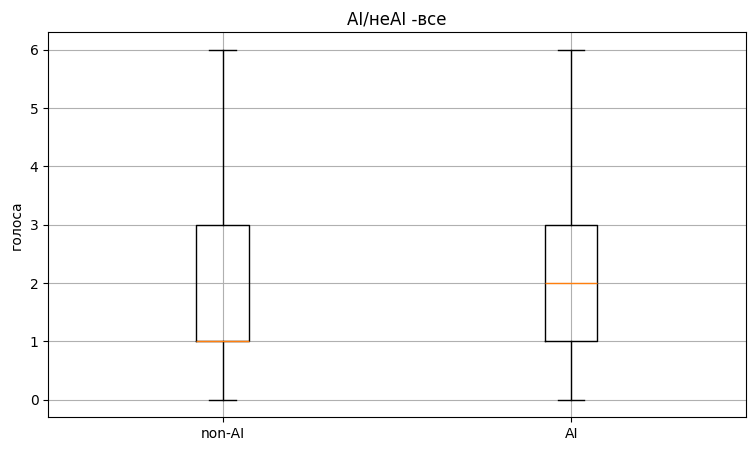

,count,mean,median,max
неAI,271,109.915129,81.0,791
AI,395,142.734177,94.0,728


/tmp/ipykernel_2134/3717201875.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_ai_votes, ai_votes], labels=["non-AI", "AI"], showfliers=False)


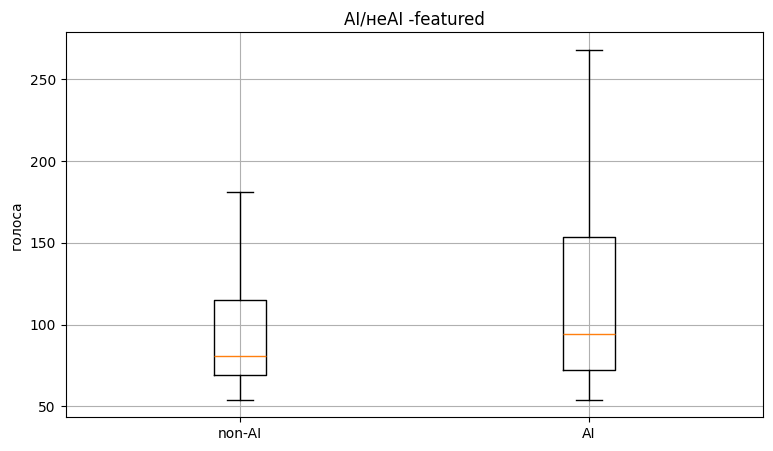

,count,mean,median,max
неAI,6527,1.973188,1.0,60
AI,4146,2.664014,2.0,152


/tmp/ipykernel_2134/3717201875.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_ai_votes, ai_votes], labels=["non-AI", "AI"], showfliers=False)


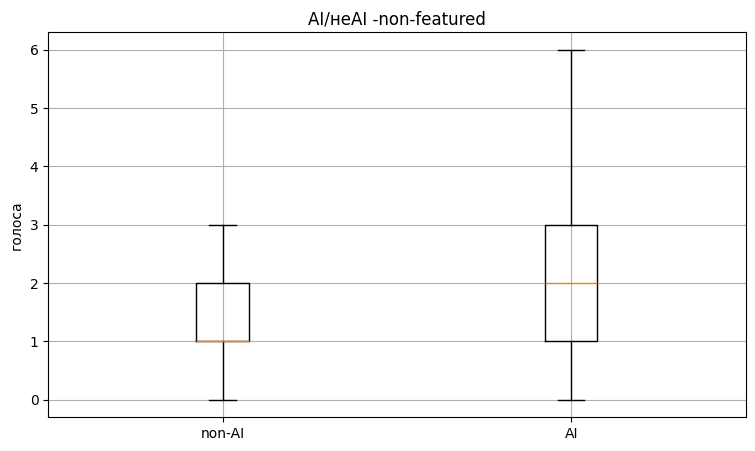

In [82]:
for segment_name, part in segments.items():
    ai_votes = part[part["is_ai_topic"] == 1]["votes_count"].dropna()
    non_ai_votes = part[part["is_ai_topic"] == 0]["votes_count"].dropna()

    stat = part.groupby("is_ai_topic")["votes_count"].agg(["count", "mean", "median", "max"])
    stat.index = ["неAI", "AI"]
    display(stat)

    plt.boxplot([non_ai_votes, ai_votes], labels=["non-AI", "AI"], showfliers=False)
    plt.title("AI/неAI -" + segment_name)
    plt.ylabel("голоса")
    plt.show()

2.AI и медиана

,count,mean,median
неAI,6798,6.276258,1.0
AI,4541,14.848051,2.0


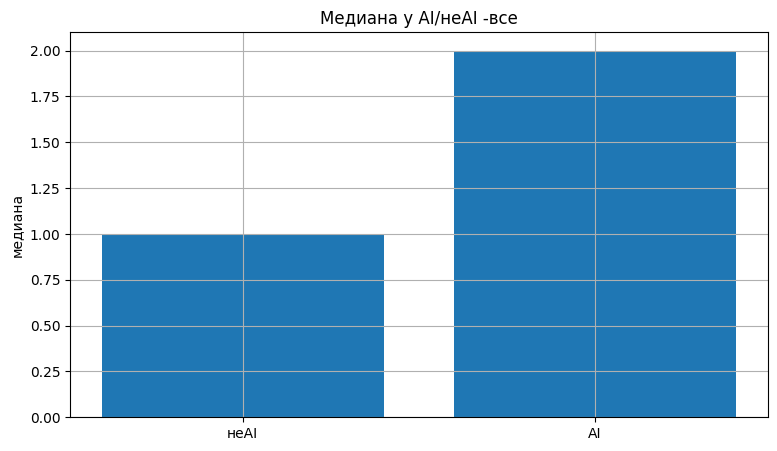

,count,mean,median
неAI,271,109.915129,81.0
AI,395,142.734177,94.0


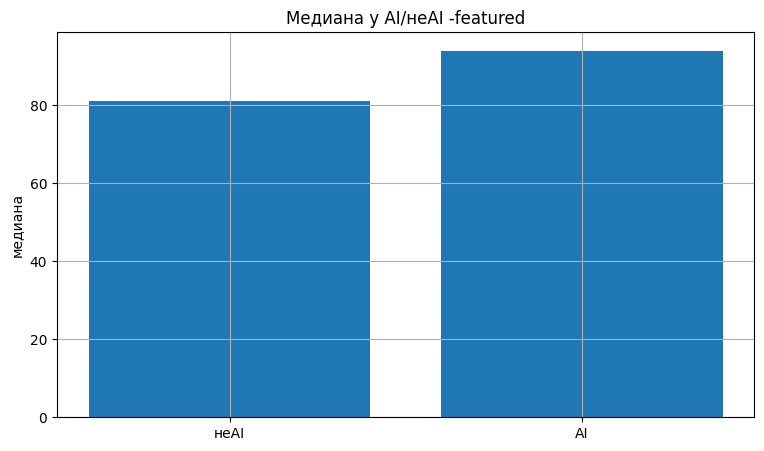

,count,mean,median
неAI,6527,1.973188,1.0
AI,4146,2.664014,2.0


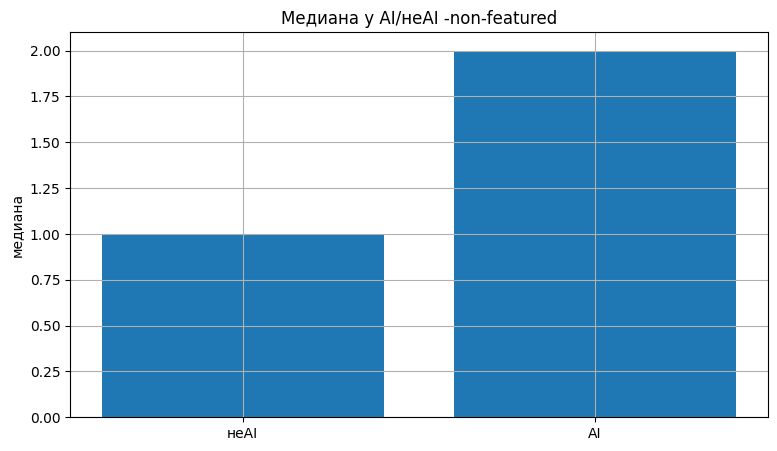

In [70]:
for segment_name, part in segments.items():
    stat = part.groupby("is_ai_topic")["votes_count"].agg(["count", "mean", "median"])
    stat.index = ["неAI", "AI"]
    display(stat)

    plt.bar(stat.index, stat["median"])
    plt.title("Медиана у AI/неAI -" + segment_name)
    plt.ylabel("медиана")
    plt.show()

3.топ категорий по медиане голосов

,count,mean,median
primary_topic,,,
Pitch Singapore,34,68.147059,70.5
Pitch Dubai,33,56.363636,64.0
Pitch Tel Aviv,33,60.575758,62.0
Pitch NYC,68,51.514706,59.5
Robots,7,40.428571,17.0
Text Editors,5,145.800000,14.0
Mac,111,31.828829,4.0
Storage,8,26.250000,3.5
Linux,5,50.400000,3.0


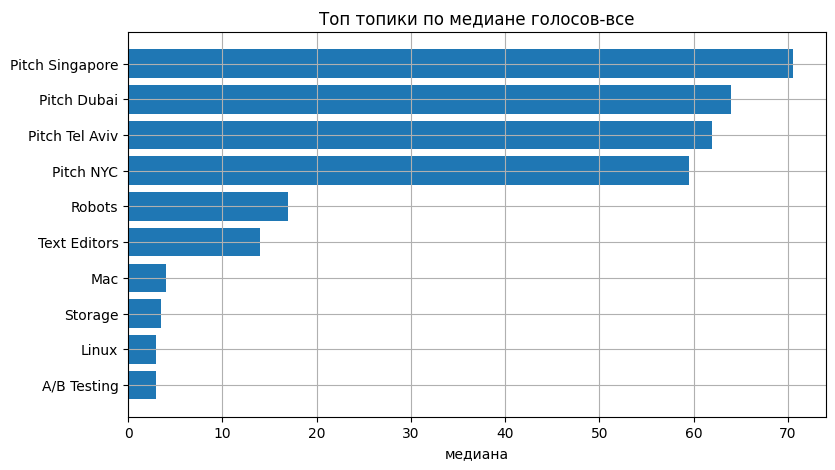

,count,mean,median
primary_topic,,,
Email,5,297.400000,260.0
Marketing,13,217.692308,147.0
Hiring,9,165.333333,133.0
API,18,149.666667,118.0
Education,6,176.500000,117.0
Analytics,10,124.800000,109.0
Travel,5,129.000000,108.0
Productivity,101,165.297030,106.0
Sales,5,125.000000,104.0


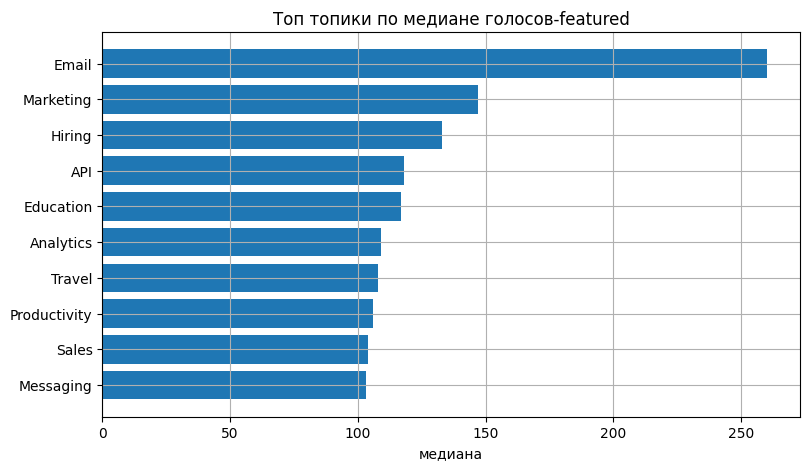

,count,mean,median
primary_topic,,,
Pitch Dubai,7,11.285714,13.0
Pitch NYC,19,7.315789,4.0
Mac,78,3.397436,3.0
Soccer,5,2.200000,3.0
A/B Testing,6,5.833333,3.0
Website Builder,19,3.789474,3.0
Storage,6,3.500000,3.0
Chrome Extensions,286,2.839161,2.0
Customer Communication,20,2.050000,2.0


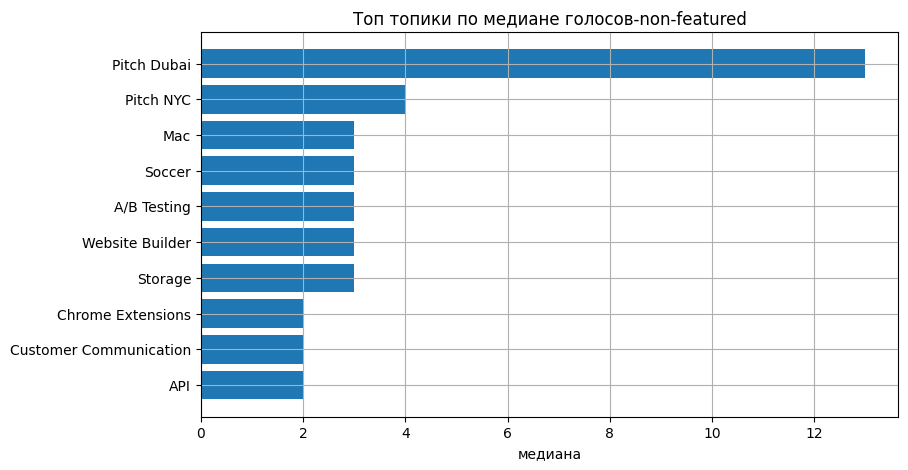

In [71]:
for segment_name, part in segments.items():
    topic_stats = part.groupby("primary_topic")["votes_count"].agg(["count", "mean", "median"])
    topic_stats = topic_stats[topic_stats["count"] >= 5]
    topic_stats = topic_stats.sort_values("median", ascending=False).head(10)

    display(topic_stats)

    plt.barh(topic_stats.index, topic_stats["median"])
    plt.title("Топ топики по медиане голосов-" + segment_name)
    plt.xlabel("медиана")
    plt.gca().invert_yaxis()
    plt.show()

4.самые частые и и их голоса

,count,mean,median
primary_topic,,,
Android,727,4.426410,2.0
Artificial Intelligence,323,18.888545,2.0
Chrome Extensions,307,9.364821,2.0
Developer Tools,311,20.617363,2.0
Fintech,301,8.807309,2.0
SaaS,494,5.327935,2.0
Productivity,2310,9.343290,2.0
Design Tools,649,9.141757,1.0
Marketing,429,9.393939,1.0


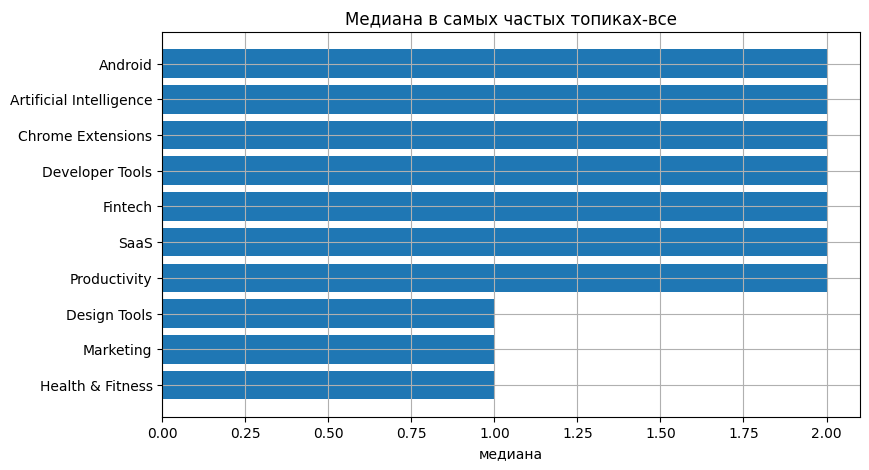

,count,mean,median
primary_topic,,,
Productivity,101,165.297030,106.0
Artificial Intelligence,32,165.218750,100.0
Developer Tools,38,146.868421,96.5
Open Source,46,142.217391,96.0
Mac,33,99.030303,92.0
Design Tools,34,134.852941,91.5
Pitch Singapore,31,73.387097,72.0
Pitch Dubai,26,68.500000,66.0
Pitch Tel Aviv,30,65.633333,63.5


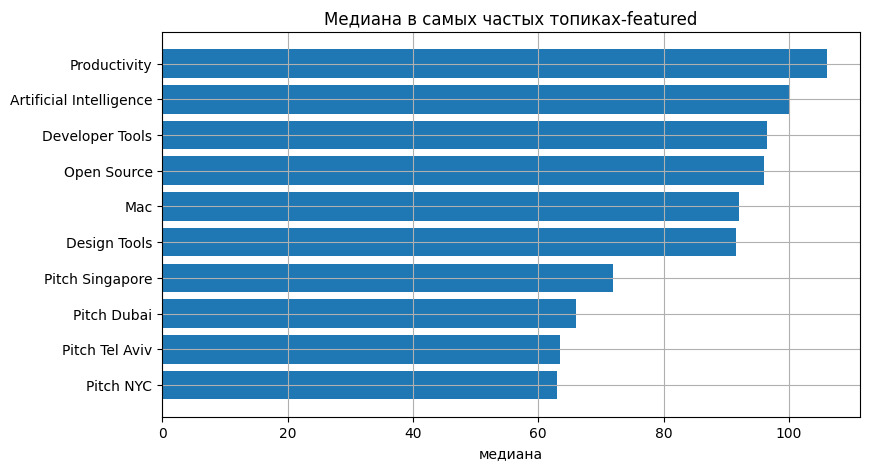

,count,mean,median
primary_topic,,,
Developer Tools,273,3.043956,2.0
Chrome Extensions,286,2.839161,2.0
Fintech,284,1.936620,2.0
Productivity,2209,2.212766,2.0
Artificial Intelligence,291,2.797251,1.0
Android,711,1.919831,1.0
Design Tools,615,2.191870,1.0
Health & Fitness,430,1.781395,1.0
Marketing,416,2.884615,1.0


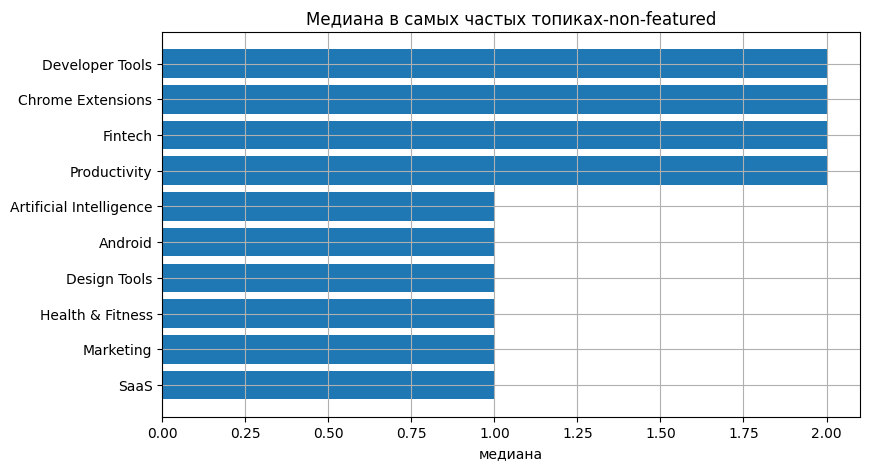

In [72]:
for segment_name, part in segments.items():
    top_topics = part["primary_topic"].value_counts().head(10).index
    temp = part[part["primary_topic"].isin(top_topics)].copy()

    topic_stats = temp.groupby("primary_topic")["votes_count"].agg(["count", "mean", "median"])
    topic_stats = topic_stats.sort_values("median", ascending=False)

    display(topic_stats)

    plt.barh(topic_stats.index, topic_stats["median"])
    plt.title("Медиана в самых частых топиках-" + segment_name)
    plt.xlabel("медиана")
    plt.gca().invert_yaxis()
    plt.show()

5.Размер аудитории по макс топикам

,max_topic_followers,votes_count
max_topic_followers,1.000000,0.044404
votes_count,0.044404,1.000000


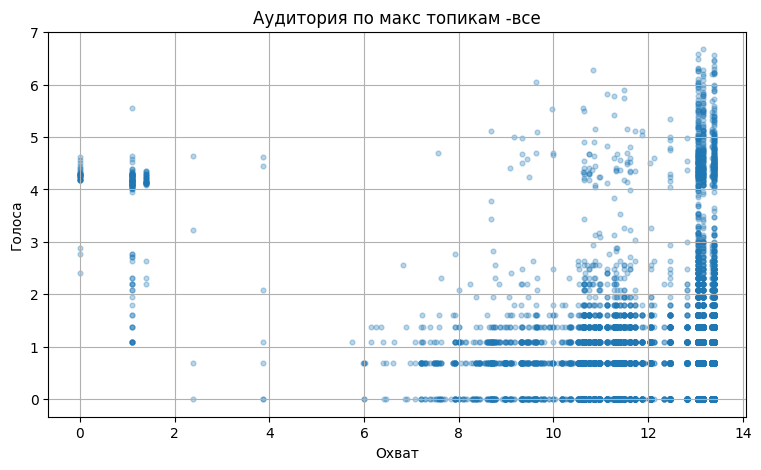

,max_topic_followers,votes_count
max_topic_followers,1.000000,0.364566
votes_count,0.364566,1.000000


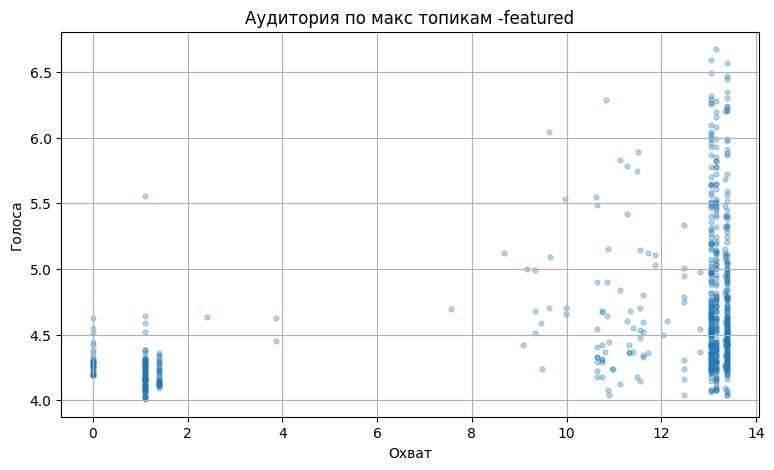

,max_topic_followers,votes_count
max_topic_followers,1.000000,0.067356
votes_count,0.067356,1.000000


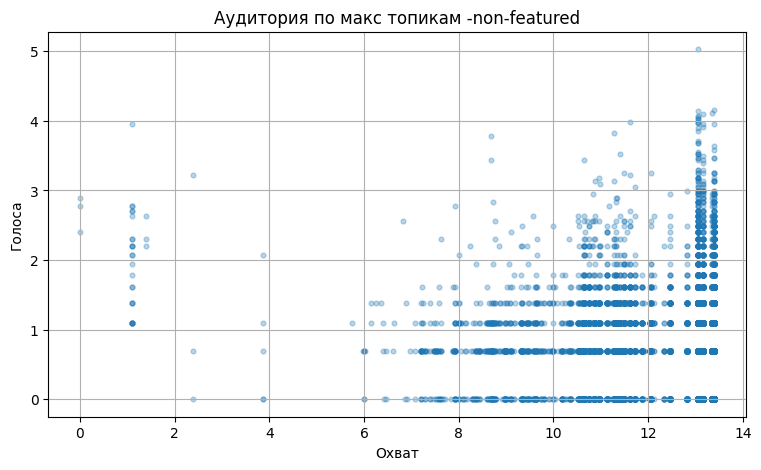

In [73]:
for segment_name, part in segments.items():
    temp = part[["max_topic_followers", "votes_count"]].dropna().copy()
    temp["log_max_topic_followers"] = np.log1p(temp["max_topic_followers"])
    temp["log_votes"] = np.log1p(temp["votes_count"])

    display(temp[["max_topic_followers", "votes_count"]].corr(method="spearman"))

    plt.scatter(temp["log_max_topic_followers"], temp["log_votes"], alpha=0.3, s=12)
    plt.title("Аудитория по макс топикам -" + segment_name)
    plt.xlabel("Охват")
    plt.ylabel("Голоса")
    plt.show()

6.Размер аудитории по сред топиков

,avg_topic_followers,votes_count
avg_topic_followers,1.000000,0.021872
votes_count,0.021872,1.000000


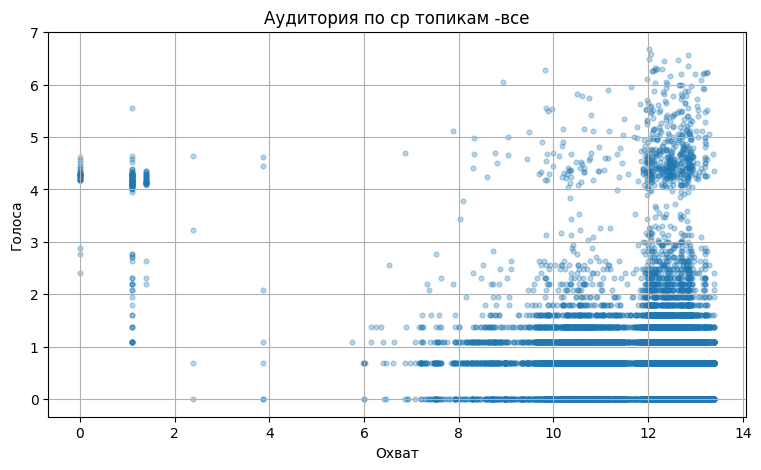

,avg_topic_followers,votes_count
avg_topic_followers,1.000000,0.410091
votes_count,0.410091,1.000000


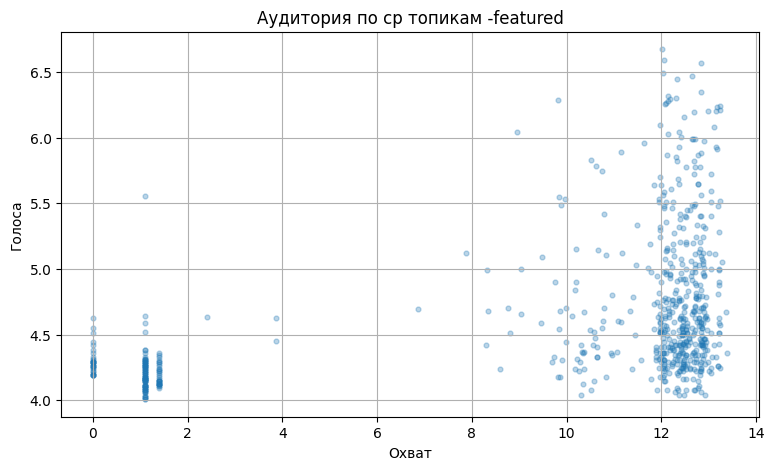

,avg_topic_followers,votes_count
avg_topic_followers,1.000000,0.040687
votes_count,0.040687,1.000000


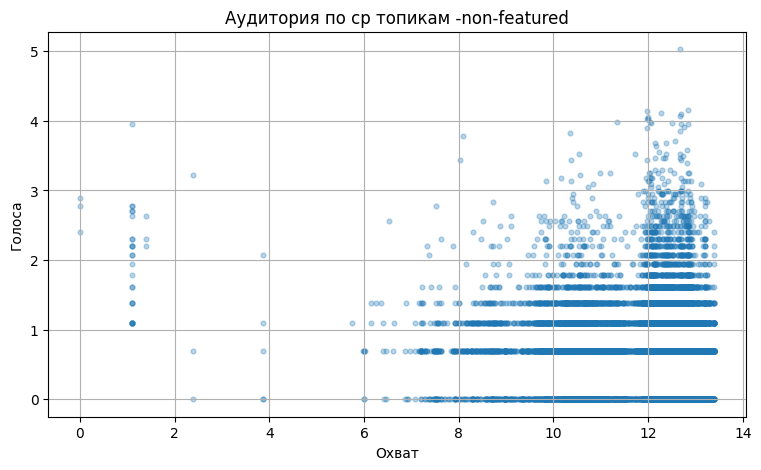

In [74]:
for segment_name, part in segments.items():
    temp = part[["avg_topic_followers", "votes_count"]].dropna().copy()
    temp["log_avg_topic_followers"] = np.log1p(temp["avg_topic_followers"])
    temp["log_votes"] = np.log1p(temp["votes_count"])

    display(temp[["avg_topic_followers", "votes_count"]].corr(method="spearman"))

    plt.scatter(temp["log_avg_topic_followers"], temp["log_votes"], alpha=0.3, s=12)
    plt.title("Аудитория по ср топикам -" + segment_name)
    plt.xlabel("Охват")
    plt.ylabel("Голоса")
    plt.show()

7.кол-во топиков и кол-во голосов

,count,mean,median
topics_count,,,
1,1280,10.270312,1.0
2,1217,7.671323,1.0
3,7686,9.489201,2.0
4,1115,12.348879,2.0
5,40,22.600000,3.0
6,1,2.000000,2.0


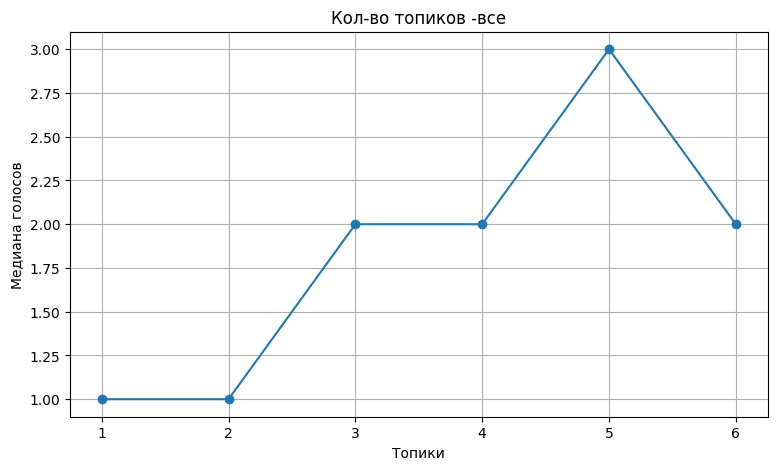

,count,mean,median
topics_count,,,
1,153,75.640523,67.0
2,44,164.454545,107.0
3,388,143.079897,98.5
4,77,143.701299,95.0
5,4,194.500000,139.5


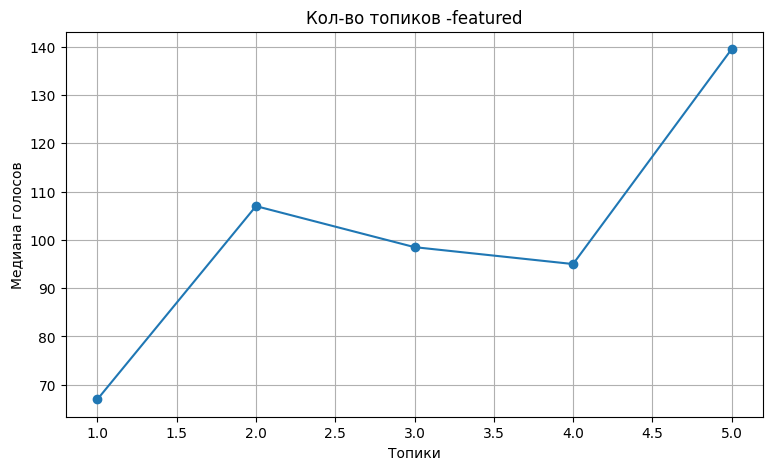

,count,mean,median
topics_count,,,
1,1127,1.395741,1.0
2,1173,1.790281,1.0
3,7298,2.386818,2.0
4,1038,2.605010,2.0
5,36,3.500000,2.0
6,1,2.000000,2.0


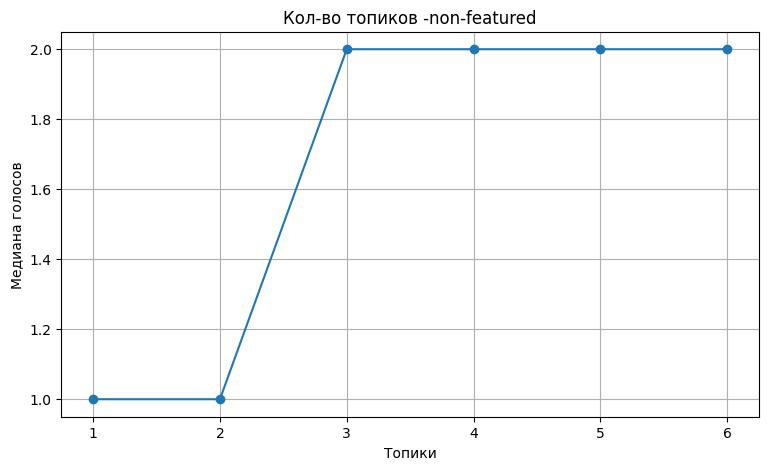

In [75]:
for segment_name, part in segments.items():
    topic_count_stats = part.groupby("topics_count")["votes_count"].agg(["count", "mean", "median"])
    display(topic_count_stats)

    plt.plot(topic_count_stats.index, topic_count_stats["median"], marker="o")
    plt.title("Кол-во топиков -" + segment_name)
    plt.xlabel("Топики")
    plt.ylabel("Медиана голосов")
    plt.show()

8. Связь длины тэглайн и кол-ва голосов

,count,mean,median
tagline_len_group,,,
"(-0.001, 10.0]",83,1.084337,1.0
"(10.0, 20.0]",265,2.377358,1.0
"(20.0, 30.0]",903,6.110742,1.0
"(30.0, 40.0]",1925,10.155844,2.0
"(40.0, 50.0]",3289,11.367893,2.0
"(50.0, 60.0]",4874,9.625359,2.0
"(60.0, 70.0]",0,NaN,NaN


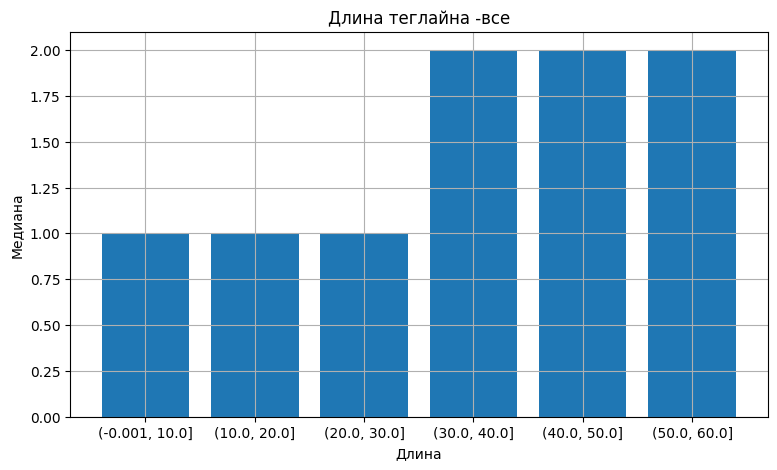

,count,mean,median
tagline_len_group,,,
"(-0.001, 10.0]",0,NaN,NaN
"(10.0, 20.0]",3,70.000000,75.0
"(20.0, 30.0]",30,125.400000,88.5
"(30.0, 40.0]",126,123.444444,93.5
"(40.0, 50.0]",252,119.876984,81.0
"(50.0, 60.0]",255,142.870588,94.0
"(60.0, 70.0]",0,NaN,NaN


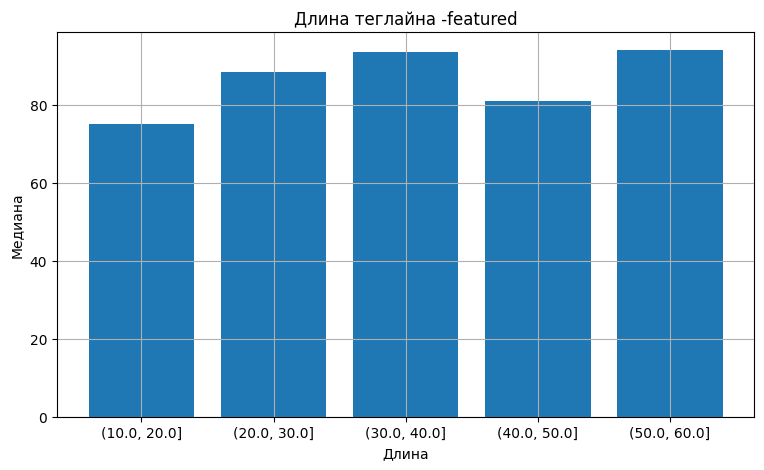

,count,mean,median
tagline_len_group,,,
"(-0.001, 10.0]",83,1.084337,1.0
"(10.0, 20.0]",262,1.603053,1.0
"(20.0, 30.0]",873,2.011455,1.0
"(30.0, 40.0]",1799,2.221234,1.0
"(40.0, 50.0]",3037,2.364175,1.0
"(50.0, 60.0]",4619,2.269322,2.0
"(60.0, 70.0]",0,NaN,NaN


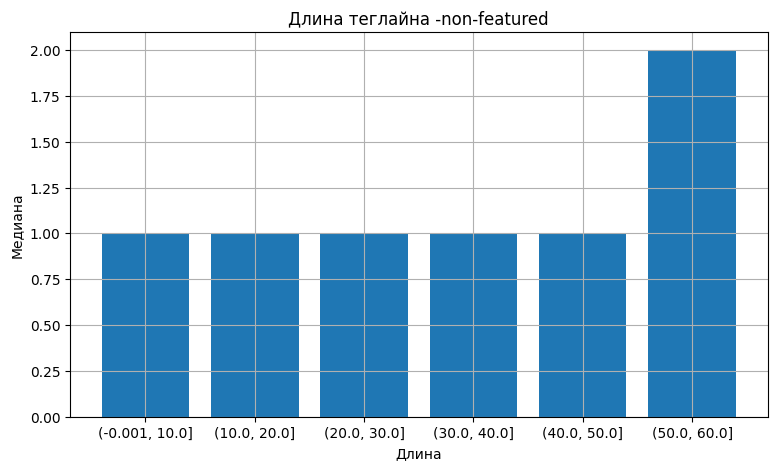

In [76]:
df["tagline_len_group"] = pd.cut(df["tagline_len"],bins=[0, 10, 20, 30, 40, 50,60, 70],include_lowest=True)

df_featured = df[df["is_featured"] == 1].copy()
df_non_featured = df[df["is_featured"] == 0].copy()

segments = {
    "все": df,
    "featured": df_featured,
    "non-featured": df_non_featured
}

for segment_name, part in segments.items():
    tagline_stats = part.groupby("tagline_len_group", observed=False)["votes_count"].agg(["count", "mean", "median"])

    display(tagline_stats)

    plt.bar(tagline_stats.index.astype(str), tagline_stats["median"])
    plt.title("Длина теглайна -" + segment_name)
    plt.xlabel("Длина")
    plt.ylabel("Медиана")
    plt.show()

In [77]:
df.to_csv("product_hunt_gp4.csv", index=False, encoding="utf-8-sig")